In [3]:
# Source for code plotting TEMPO PM2.5 data:
# NOAA/NESDIS Aerosols & Atmospheric Composition Science Team

# ABI-Estimated Hourly Surface PM2.5 Product Data Tutorial
# Dr. Amy Huff (amy.huff@noaa.gov)
# https://gist.github.com/akhuff157/491d0ebe44a9a6a27baeb6b0e7013cae

### **Prep: libraries, read files, etc.**

In [4]:
# Import modules and libraries

from pathlib import Path

import xarray as xr
import polars as pl

import matplotlib.colorbar as mcolorbar
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime as dt
# date and time inputs
date = 20250418     # YYYYMMDD
hour = 18           # synoptic hour -- no trailing zeros
# domain
x1 = -75.1                   # Easternmost longitude
x2 = -84.6                   # Westernmost longitude
y1 = 37.5                    # Northernmost Latitude
y2 = 33.25                    # Southernmost Latitude

#### Colorbar

In [5]:
# create PM2.5 colormap, set geographic domain

# Create colormap for PM2.5 (based on AQI) using matplotlib
aqi_cmap = mcolors.ListedColormap(['limegreen', 'yellow', 'orange',
                                      'red', 'darkorchid', 'firebrick'])

bounds = [0, 9.1, 35.5, 55.5, 125.5, 225.5, 500]
cmap_norm = mcolors.BoundaryNorm(bounds, aqi_cmap.N)

# Function to save colorbar as an image to add to poster or whatev
def save_cbar(colors = aqi_cmap, 
              norm = cmap_norm,
              bounds: list[int] = bounds,
              # Could add something so it's usable for other pollutants
              ticklabel_size: int = 18,
              label_size: int = 18,
              bg_transparency: bool = True):
    
    # configure in mpl
    fig = plt.figure()
    ax = fig.add_axes((0.05, 0.80, 0.9, 0.1))

    # create colorbar
    cb = mcolorbar.ColorbarBase(ax,
                                orientation='horizontal',
                                cmap=colors,norm=norm,
                                ticks=bounds,
                                spacing='uniform',
                                extend='max')
    
    # set label, ticks
    cb.set_label(label=
                 r'PM$_{2.5}$ Concentration '
                 r'($\mu$g m$\mathregular{^{-3}}$)',
                 size=label_size, weight='bold')
    cb.ax.set_xticklabels([str(x) for x in bounds])
    cb.ax.tick_params(labelsize=ticklabel_size)

    # save figure
    fig.savefig(Path.cwd()/'figs/aqi_cbar.svg',
                transparent=bg_transparency,
                bbox_inches='tight')

#### Open/read lat/lon, PM2.5, EPA files

In [6]:
# Open/read files -- lat/lon, PM2.5, EPA

# Open lat/lon file using xarray Dataset
lat_lon_file = Path.cwd() / 'data/tempo/estimated_pm25_interpolated_lat_lon.nc'
lat_lon_ds = xr.open_dataset(lat_lon_file, engine='netcdf4')

# Read latitude & longitude data arrays
lon_ge = lat_lon_ds.lon_ge
lat_ge = lat_lon_ds.lat_ge

# Open TEMPO-ABI PM2.5 file using xarray DataTree
pm25_file = Path.cwd() / f'data/tempo/{date}/TEMPO-ABI_PM25_L4_V01_{date}T{hour}0000Z.nc'
pm_dt = xr.open_datatree(pm25_file, engine='netcdf4')

# Read estimated PM2.5 data arrays
pm25sat_ge = pm_dt['product/pm25sat_ge']

# Pull observation year & date from TEMPO-ABI PM2.5 file name
# dates/times
file_str = pm25_file.name
time = file_str.split('_')[4][9:11]
year = file_str.split('_')[4][:4]
month = file_str.split('_')[4][4:6]
day = file_str.split('_')[4][6:8]
date = file_str.split('_')[4][:8]

# EPA file
epa = (pl.scan_parquet(Path.cwd()/f'data/epa/nc_census_epa.pq')
       .filter(pl.col('timestamp') >= dt.strptime(f'{year}-{month}-{day} 13:00:00', '%Y-%m-%d %H:%M:%S'))
       .filter(pl.col('timestamp') <= dt.strptime(f'{year}-{month}-{day} 22:00:00', '%Y-%m-%d %H:%M:%S'))
       ) 

epa=epa.select(['countyFIPS','site',
                'lat','lon','date','time',
                'pm25','county','URA','popden'])
epa_df = epa.collect().to_pandas()

/var/folders/3q/qyy_jchx3n34v2hnkcrcw3qm0000gn/T/ipykernel_3698/1455422549.py:36: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.
  epa_df = epa.collect().to_pandas()


### **Plot figure**

/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/rem

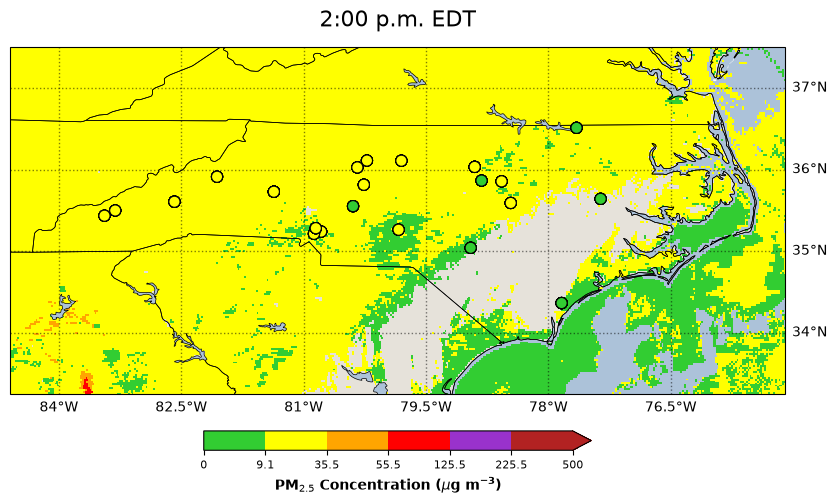

/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/stellaforeman/remus-proj/.pixi/envs/default/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


In [7]:
# Set up figure in matplotlib
fig = plt.figure(figsize=(10,8))
# Set map projection using cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# Set geographic domain of map
map_domain = [x2,x1,y2,y1]
ax.set_extent(map_domain, crs=ccrs.PlateCarree())

# Format map background
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=4)
ax.add_feature(cfeature.STATES, facecolor="#e6e2da",edgecolor='none',zorder=0)
ax.add_feature(cfeature.STATES, linewidth=0.5, zorder=4)
ax.add_feature(cfeature.LAKES, facecolor='xkcd:cloudy blue',edgecolor='black',
            linewidth=0.5, zorder=4)
ax.add_feature(cfeature.OCEAN, facecolor='xkcd:cloudy blue',zorder=0)

# Open lat/lon & TEMPO-ABI PM2.5 files (automatically closes files when done)
with (xr.open_dataset(lat_lon_file, engine='netcdf4') as lat_lon_ds,
        xr.open_datatree(pm25_file, engine='netcdf4') as pm_dt):

        # Read in lat & lon data arrays, estimated PM2.5
        lon_ge = lat_lon_ds.lon_ge
        lat_ge = lat_lon_ds.lat_ge

        lon_gw = lat_lon_ds.lon_gw
        lat_gw = lat_lon_ds.lat_gw

        pm25sat_ge = pm_dt['product/pm25sat_ge']
        pm25sat_gw = pm_dt['product/pm25sat_gw']

        # Plot TEMPO estimated PM2.5 on GOES-East grid
        plot1 = ax.pcolormesh(lon_ge, lat_ge, pm25sat_ge, cmap=aqi_cmap,
                              norm=cmap_norm, transform=ccrs.PlateCarree(),
                              zorder=1)
        # # and on GOES-West grid
        # plot2 = ax.pcolormesh(lon_gw, lat_gw, pm25sat_gw, cmap=aqi_cmap,
        #                       norm=cmap_norm, transform=ccrs.PlateCarree(),
        #                       zorder=2)

# plot observed sfc data  
dot_size = 8
ax.scatter(epa_df['lon'], epa_df['lat'], 
           c=epa_df['pm25'], s=dot_size**2,
           linewidths=0.8, edgecolors='black', cmap=aqi_cmap,
           norm=cmap_norm, transform=ccrs.PlateCarree(), zorder=5)

# Add colorbar
cb = fig.colorbar(plot1, orientation='horizontal', fraction=0.2, pad=0.06,
                  shrink=0.5, ticks=bounds, spacing='uniform', extend='max')
cb.set_label(label=r'PM$_{2.5}$ Concentration ($\mu$g m$\mathregular{^{-3}}$)',
             size=10, weight='bold')
cb.ax.set_xticklabels(['0', '9.1', '35.5', '55.5', '125.5', '225.5', '500'])
cb.ax.tick_params(labelsize=8)

gl = ax.gridlines(crs=ccrs.PlateCarree(),linewidth=1, color='k',
                  alpha=0.5,linestyle=':',zorder=5)
gl.bottom_labels=True
gl.right_labels=True

# Add title
if time <= '16':
    time_edt = f'{int(time)-4}:00 a.m. EDT'
else:
    time_edt = f'{int(time)-16}:00 p.m. EDT'
ax.set_title(label=f'{time_edt}',size=16,pad=15,zorder=7)

plt.show(fig)

save_name = f'nc-map_{date}_{time}utc'

fig.savefig(Path.cwd() / f'figs/nc-map_{date}_{time}utc.png',dpi=300,bbox_inches='tight')

plt.close(fig)